# Multispectral tissue classification by spectral unmixing
### turning a stack of wavelength-band images into a labeled tumor map

A multispectral camera records, at every pixel, the brightness in many wavelength bands -- a
whole **spectrum**, not just R/G/B. Most pixels are a *mixture* of a few pure materials
(healthy tissue, tumor, background), each with its own spectral signature (an **endmember**).
The mixing is linear,
$$\mathbf{s}=E\,\mathbf{a},$$
so recovering the **abundances** $\mathbf a$ (how much of each material) is a constrained
least-squares problem -- non-negative and summing to one. The dominant abundance then
**classifies** each pixel. This notebook builds a synthetic tissue phantom, "images" it with
noise, unmixes it with `dgs/spectral_unmixing.py`, and recovers the tumor map. Civilian
education (synthetic data).

In [1]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import spectral_unmixing as su
print("ready -- numpy", np.__version__)

ready -- numpy 2.4.4


## 1. The endmember spectra

Three pure materials, each a distinct curve across 6 bands. Unmixing works only when the
endmembers are spectrally *different* -- if tumor and healthy looked identical no method could
separate them. These are the reference library the camera is matched against.

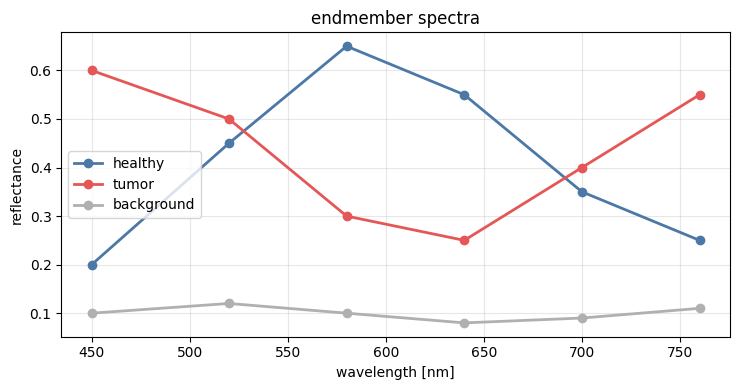

In [2]:
bands = np.array([450, 520, 580, 640, 700, 760])   # nm
healthy    = np.array([0.20, 0.45, 0.65, 0.55, 0.35, 0.25])
tumor      = np.array([0.60, 0.50, 0.30, 0.25, 0.40, 0.55])
background = np.array([0.10, 0.12, 0.10, 0.08, 0.09, 0.11])
E = np.column_stack([healthy, tumor, background])
labels = ["healthy", "tumor", "background"]
colors = ["#4C78A8", "#E45756", "#B0B0B0"]

plt.figure(figsize=(7.5, 4))
for spec, name, c in zip([healthy, tumor, background], labels, colors):
    plt.plot(bands, spec, "o-", lw=2, color=c, label=name)
plt.xlabel("wavelength [nm]"); plt.ylabel("reflectance"); plt.title("endmember spectra")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. A synthetic tissue phantom, then "imaged" with noise

Lay down ground-truth abundance maps -- a background field, a healthy-tissue region, and a
tumor blob inside it, blended smoothly and normalized so the three fractions sum to 1 at every
pixel. Multiply by the endmembers and add read noise to get the multispectral **cube** the
camera would capture (6 band images).

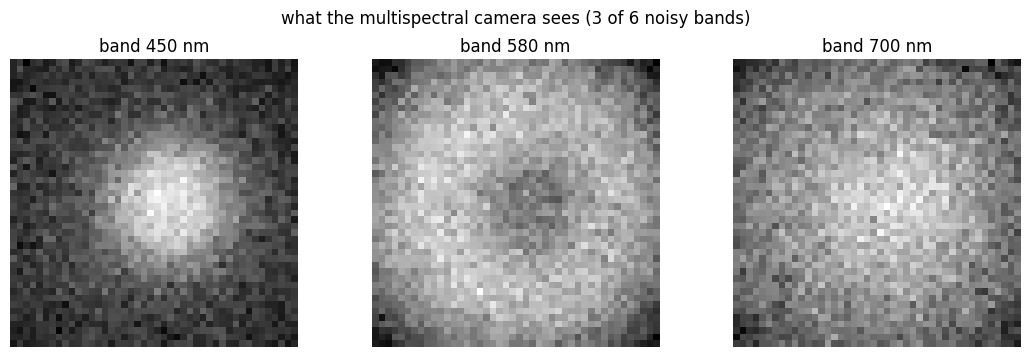

In [3]:
N = 44
yy, xx = np.mgrid[0:N, 0:N] / (N - 1)
blob = lambda cx, cy, r: np.exp(-(((xx-cx)**2 + (yy-cy)**2) / (2*r**2)))
a_tumor   = 0.95 * blob(0.55, 0.5, 0.13)
a_healthy = 0.9 * blob(0.5, 0.5, 0.34)
a_bg      = np.full((N, N), 0.15)
A_true = np.stack([a_healthy, a_tumor, a_bg], axis=-1)
A_true /= A_true.sum(axis=-1, keepdims=True)          # fractions sum to 1

cube = A_true @ E.T                                    # (N,N,6) clean spectra
rng = np.random.default_rng(0)
cube_noisy = cube + rng.normal(0, 0.02, cube.shape)   # 2% read noise

fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
for a, b in zip(ax, (0, 2, 4)):
    im = a.imshow(cube_noisy[:, :, b], cmap="gray")
    a.set_title(f"band {bands[b]} nm"); a.axis("off")
plt.suptitle("what the multispectral camera sees (3 of 6 noisy bands)")
plt.tight_layout(); plt.show()

## 3. Unmix every pixel $\to$ abundance maps

Run constrained non-negative least squares at each pixel (`unmix_cube`) to get, per material,
a map of how much of it is present. The tumor abundance map lights up exactly the blob -- even
though no single band image shows it cleanly, the *spectral* combination does.

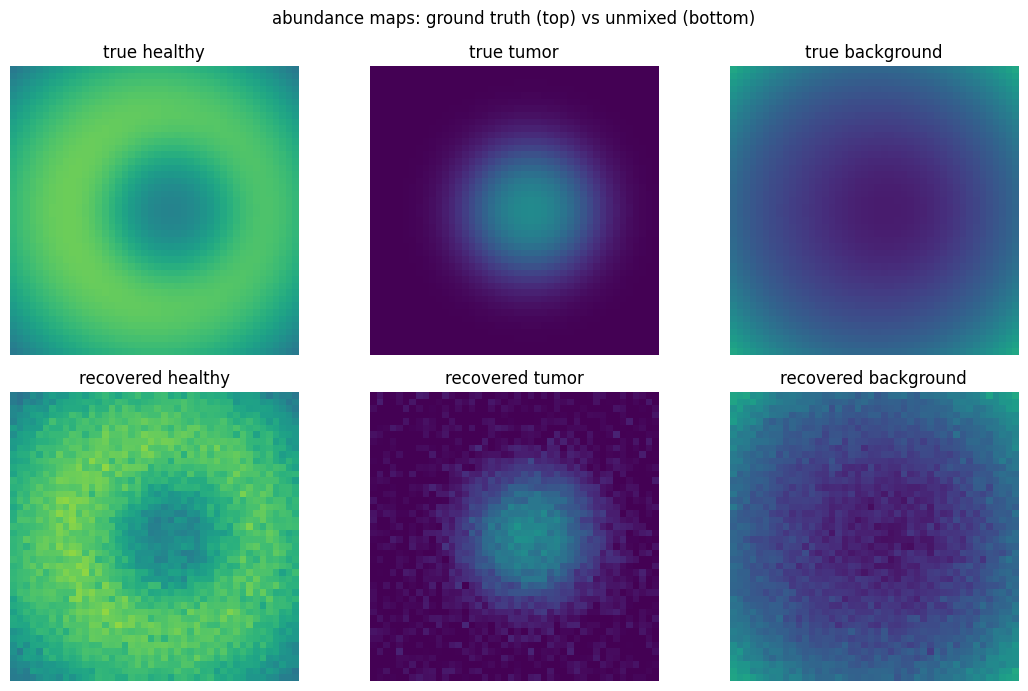

mean abundance error = 0.0209


In [4]:
A_est = su.unmix_cube(cube_noisy, E)                   # (N,N,3) recovered abundances
fig, ax = plt.subplots(2, 3, figsize=(11, 7))
for k in range(3):
    im0 = ax[0, k].imshow(A_true[:, :, k], vmin=0, vmax=1, cmap="viridis")
    ax[0, k].set_title(f"true {labels[k]}"); ax[0, k].axis("off")
    im1 = ax[1, k].imshow(A_est[:, :, k], vmin=0, vmax=1, cmap="viridis")
    ax[1, k].set_title(f"recovered {labels[k]}"); ax[1, k].axis("off")
plt.suptitle("abundance maps: ground truth (top) vs unmixed (bottom)")
plt.tight_layout(); plt.show()
print("mean abundance error =", np.mean(np.abs(A_true - A_est)).round(4))

## 4. Classify each pixel by its dominant material

Take the argmax abundance at every pixel and you have a **labeled tissue map** -- the tumor
segmented out from healthy tissue and background, straight from the spectra. Compare to ground
truth: the accuracy is the fraction of pixels labeled correctly.

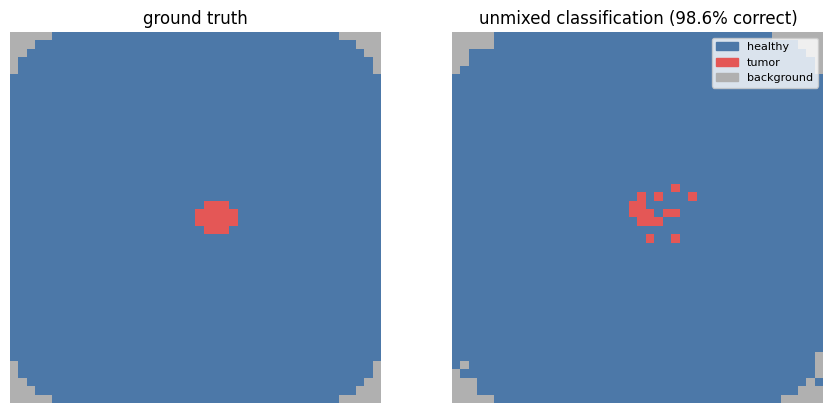

classification accuracy = 98.6%


In [5]:
cmap = ListedColormap(colors)
true_class = np.argmax(A_true, axis=-1)
pred_class = np.argmax(A_est, axis=-1)
acc = np.mean(true_class == pred_class)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
ax[0].imshow(true_class, cmap=cmap, vmin=0, vmax=2); ax[0].set_title("ground truth"); ax[0].axis("off")
ax[1].imshow(pred_class, cmap=cmap, vmin=0, vmax=2)
ax[1].set_title(f"unmixed classification ({acc:.1%} correct)"); ax[1].axis("off")
from matplotlib.patches import Patch
ax[1].legend(handles=[Patch(color=colors[i], label=labels[i]) for i in range(3)],
             loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()
print(f"classification accuracy = {acc:.1%}")

## 5. One pixel, close up

Pick a mixed pixel on the tumor edge: its measured spectrum is a blend, and unmixing splits it
into fractions whose reconstruction $E\mathbf a$ matches the measurement. That per-pixel fit,
repeated everywhere, is the whole method.

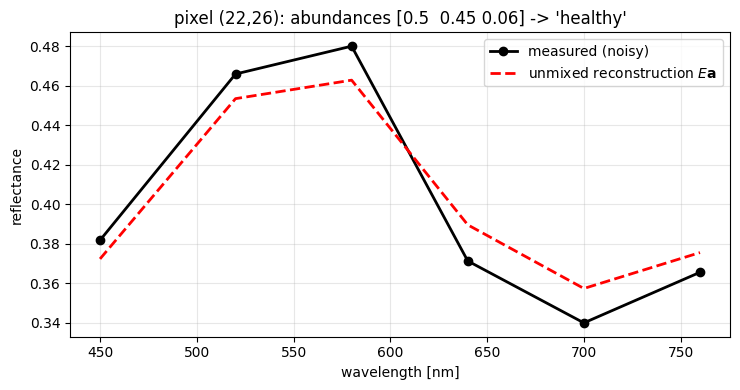

reconstruction RMS error = 1.458e-02


In [6]:
i, j = 22, 26
s = cube_noisy[i, j]
a = su.unmix_fractional(s, E)
plt.figure(figsize=(7.5, 4))
plt.plot(bands, s, "ko-", lw=2, label="measured (noisy)")
plt.plot(bands, su.reconstruct(a, E), "r--", lw=2, label="unmixed reconstruction $E\\mathbf{a}$")
plt.xlabel("wavelength [nm]"); plt.ylabel("reflectance")
plt.title(f"pixel ({i},{j}): abundances {np.round(a,2)} -> '{labels[int(np.argmax(a))]}'")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("reconstruction RMS error = %.3e" % su.reconstruction_error(s, a, E))

## What we did

* A multispectral pixel is a linear mix $\mathbf s=E\mathbf a$ of pure-material spectra; the
  **abundances** solve a non-negative, sum-to-one least-squares problem.
* Unmixing every pixel turns a noisy 6-band cube into clean **abundance maps** and a
  **classified tissue map** -- the tumor segmented from healthy tissue and background.
* Same $A\mathbf x=\mathbf b$ least squares as `dgs/gnss_positioning.py` and
  `dgs/statics_linalg.py`, now with $\mathbf a\ge0$ -- the multispectral-imaging front end of
  a cell/tissue classifier, and the CPU ground truth a CUDA version would parallelize.